#### tune, train, test XGB regressor

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import joblib

In [ ]:
# set seed for reproducibility
seed=1234

In [ ]:
# dataset
df = pd.read_csv("datasets/final_ds.csv")
target_cols = [f"NCAR{i}" for i in range(1,21)]
subset = target_cols + ['stage', 'date']
df_clean = df.dropna(subset=subset).reset_index(drop=True)

In [4]:
df_clean['date'] = pd.to_datetime(df_clean['date'])

In [ ]:
# masks to create train/ validation/ test datasets
train_mask = (df_clean['date'] >= '2025-01-01') & (df_clean['date'] <= '2025-9-30')
val_mask = (df_clean['date'] >= '2025-10-01') & (df_clean['date'] <= '2025-11-30')
test_mask = (df_clean['date'] >= '2026-01-01') & (df_clean['date'] <= '2026-06-30')

In [ ]:
# define evalaution metric
models = {}
eval_metrics = []

def eval_rank_ic(y_true, y_pred):
    rank_ic, _ = spearmanr(y_true, y_pred)
    if np.isnan(rank_ic):
        return 0
    return float(-rank_ic)

In [ ]:
# train and test the model for each of the 20 days post catalysts
for dayX in range(1,21):
    target = f'NCAR{dayX}'
    features = ['polarity',
                # 'drug_count',
                'Total Revenue', 
                'Operating Revenue', 
                'Cash And Cash Equivalents', 
                'Capital Expenditure', 
                'Stock_Trend_30d', 
                'Stock_Trend_60d',
                # 'NBI_Trend_30d', 
                'NBI_Trend_60d'
                # 'isDelisted'
                ]


    X_train = df_clean.loc[train_mask, features].copy()
    y_train = df_clean.loc[train_mask, target].copy()

    X_val = df_clean.loc[val_mask, features].copy()
    y_val = df_clean.loc[val_mask, target].copy()

    X_test = df_clean.loc[test_mask, features].copy()
    y_test = df_clean.loc[test_mask, target].copy()

    # X_train['stage'] = X_train['stage'].astype('category')
    # X_test['stage'] = X_test['stage'].astype('category')

    # X_train['isDelisted'] = X_train['isDelisted'].astype('int')
    # X_test['isDelisted'] = X_test['isDelisted'].astype('int')

    cont_vars = [c for c in features if (c != 'stage' and c!= 'isDelisted')]
    X_train[cont_vars] = X_train[cont_vars].apply(pd.to_numeric)
    X_test[cont_vars] = X_test[cont_vars].apply(pd.to_numeric)

    y_train = y_train.apply(pd.to_numeric)
    y_test = y_test.apply(pd.to_numeric)

    print(f"Train observation count: {len(X_train)}")
    print(f"Validation observation count: {len(X_val)}")
    print(f"Test observation count: {len(X_test)}")

    model = xgb.XGBRegressor(
        objective = 'reg:pseudohubererror',
        huber_slope = 1.0,
        eval_metric = eval_rank_ic,
        n_estimators = 50,
        learning_rate = 0.03,
        max_depth=2,
        random_state = seed,
        n_jobs = 1,
        tree_method = "hist",
        min_child_weight = 25,
        # colsample_bytree = 0.6,
        max_delta_step = 1,
        enable_categorical = True,
        missing = np.nan,
        reg_alpha = 2,
        reg_lambda = 15,
        early_stopping_rounds = 15    
        )


    model.fit(X_train,
            y_train,
            eval_set = [(X_train, y_train), (X_val, y_val)],
            verbose= False
            )

    model.save_model("model.json")

    models[dayX] = model

    y_pred = model.predict(X_test)

    # model evaluation
    rank_ic, p_val = spearmanr(y_test, y_pred)

    eval_metrics.append({
        "Day": dayX,
        "Directional Accuracy": np.mean(np.sign(y_pred) == np.sign(y_test)),
        "Rank IC": rank_ic, 
        "p_val": p_val,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    })

    # feature imporatance
    importance = pd.DataFrame({
        'Features' : features,
        'Importance': models[dayX].feature_importances_
    }).sort_values('Importance', ascending = False)

    print(importance)

Train observation count: 1792
Validation observation count: 524
Test observation count: 1477
                    Features  Importance
5            Stock_Trend_30d    0.175977
4        Capital Expenditure    0.161703
1              Total Revenue    0.148295
7              NBI_Trend_60d    0.129041
0                   polarity    0.118481
3  Cash And Cash Equivalents    0.107125
2          Operating Revenue    0.091441
6            Stock_Trend_60d    0.067936
Train observation count: 1792
Validation observation count: 524
Test observation count: 1477
                    Features  Importance
5            Stock_Trend_30d    0.212404
6            Stock_Trend_60d    0.187241
4        Capital Expenditure    0.178838
0                   polarity    0.174170
7              NBI_Trend_60d    0.154716
3  Cash And Cash Equivalents    0.092632
1              Total Revenue    0.000000
2          Operating Revenue    0.000000
Train observation count: 1792
Validation observation count: 524
Test observa

In [8]:
eval_metrics = pd.DataFrame(eval_metrics)
print(eval_metrics)

    Day  Directional Accuracy   Rank IC         p_val      RMSE       MAE  \
0     1              0.514557  0.063694  1.435387e-02  0.355725  0.070637   
1     2              0.491537  0.112075  1.580097e-05  1.041041  0.107718   
2     3              0.534868  0.172459  2.517567e-11  0.791949  0.125376   
3     4              0.496953  0.166508  1.204517e-10  0.720985  0.137604   
4     5              0.555179  0.162790  3.113295e-10  0.726940  0.151157   
5     6              0.543670  0.168779  6.671110e-11  0.725263  0.160132   
6     7              0.547055  0.155673  1.805135e-09  0.528869  0.161171   
7     8              0.482058  0.116731  6.866585e-06  0.704418  0.183871   
8     9              0.474611  0.130821  4.532723e-07  1.021416  0.203938   
9    10              0.527420  0.202022  4.561173e-15  0.952330  0.200271   
10   11              0.491537  0.199639  9.627954e-15  1.000304  0.212519   
11   12              0.507786  0.212838  1.365681e-16  0.576080  0.202962   

In [9]:
# check for overfitting
y_train_pred = model.predict(X_train)
rank_ic_train, p_val_train = spearmanr(y_train, y_train_pred)
print(rank_ic_train)

0.37102212177232424


In [ ]:
# extract data for the plot
results = model.evals_result()
train_rank_ic = [-x for x in results["validation_0"]['eval_rank_ic']]
test_rank_ic = [-x for x in results["validation_1"]['eval_rank_ic']]
best = model.best_iteration
print(best)

12


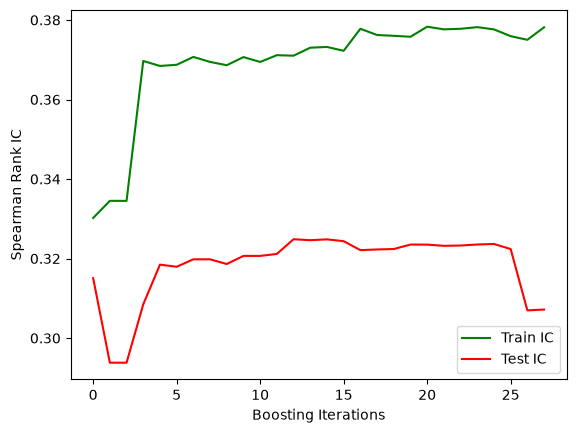

In [11]:
# plot learning curves

plt.figure()
plt.plot(train_rank_ic, label = "Train IC", color= 'green')
plt.plot(test_rank_ic, label = "Test IC", color = 'red')
plt.ylabel("Spearman Rank IC")
plt.xlabel("Boosting Iterations")
plt.legend()
plt.show()

In [ ]:
# save models
joblib.dump(models, "xgb_models_1_to_20.joblib")

['xgb_models_1_to_20.joblib']